## Global Variables

In [1]:
DATA_PATH = "/kaggle/input/datasets/ealaxi/paysim1/PS_20174392719_1491204439457_log.csv"

RANDOM_NUMBER = 37

## EDA

In [2]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

In [3]:
dataset = pd.read_csv(DATA_PATH)

In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [5]:
dataset.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [6]:
dataset['type'].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [7]:
# Check for zero and negative values in the "amount" column
print(f"Zero values: {(dataset['amount'] == 0).sum()}")
print(f"Negative values: {(dataset['amount'] < 0).sum()}")
print(f"Min value: {dataset['amount'].min()}")
print(f"Max value: {dataset['amount'].max()}")

Zero values: 16
Negative values: 0
Min value: 0.0
Max value: 92445516.64


In [8]:
# Skewness before transformation
original_skewness = stats.skew(dataset['amount'].to_numpy())
print(f"Original Skewness: {original_skewness}")

Original Skewness: 30.99394217560625


In [9]:
# Apply log transformation (using log1p due to the presence of zero values => log1p(x) = Ln(1 + x))
log_amount = np.log1p(dataset['amount'])
log_skewness = stats.skew(log_amount)
print(f"Log-Transformed Skewness: {log_skewness}")

Log-Transformed Skewness: -0.5550181895761241


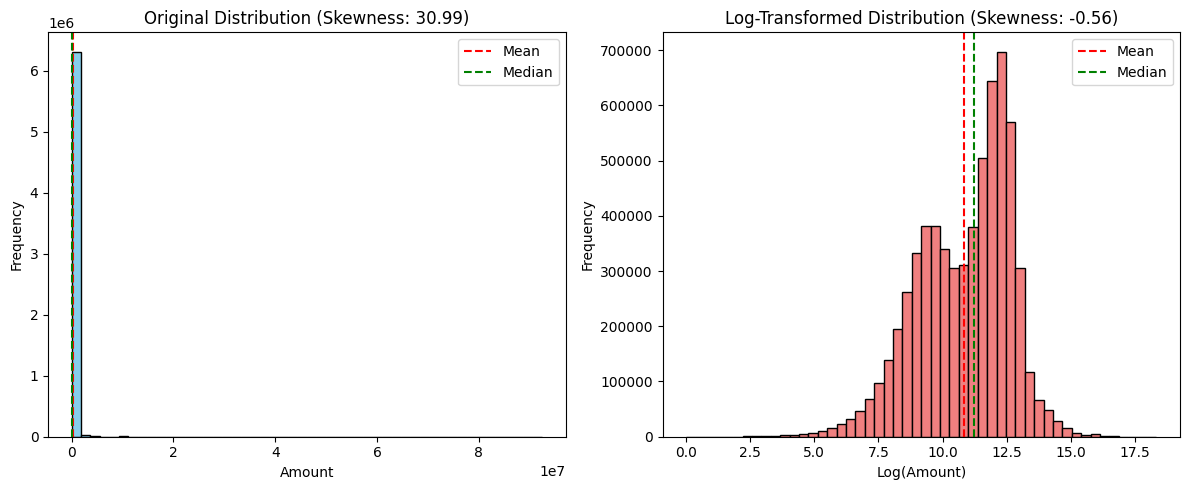

In [10]:
# Visualizion before and after transformation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original distribution
axes[0].hist(dataset['amount'], bins=50, edgecolor='black', color='skyblue')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Original Distribution (Skewness: {original_skewness:.2f})')
axes[0].axvline(dataset['amount'].mean(), color='red', linestyle='--', label='Mean')
axes[0].axvline(dataset['amount'].median(), color='green', linestyle='--', label='Median')
axes[0].legend()

# Log-transformed distribution
axes[1].hist(log_amount, bins=50, edgecolor='black', color='lightcoral')
axes[1].set_xlabel('Log(Amount)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Log-Transformed Distribution (Skewness: {log_skewness:.2f})')
axes[1].axvline(log_amount.mean(), color='red', linestyle='--', label='Mean')
axes[1].axvline(log_amount.median(), color='green', linestyle='--', label='Median')
axes[1].legend()

plt.tight_layout()
plt.show()

In [11]:
from math import pi

def make_hour(X):
    return (X - 1) % 24

def make_day(X):
    return ((X - 1) // 24) + 1

def make_hour_sine(X):
    hour = make_hour(X)
    return np.sin((2 * pi * hour) / 24)


def make_day_of_week(X):
    """Convert step to day of week (assumming 0=Monday, 6=Sunday)"""
    day = ((X - 1) // 24) + 1
    return (day - 1) % 7

def make_day_of_week_sine(X):
    """Sine encoding for day of week"""
    dow = make_day_of_week(X)
    return np.sin((2 * pi * dow) / 7)


fraud_transactions = dataset[dataset['isFraud'] == 1]

step = fraud_transactions['step'].values
hours = make_hour(fraud_transactions['step'])
days = make_day(fraud_transactions['step'])
hour_sine = make_hour_sine(fraud_transactions['step'])

day_of_week = make_day_of_week(fraud_transactions['step'])
dow_sine = make_day_of_week_sine(fraud_transactions['step'])

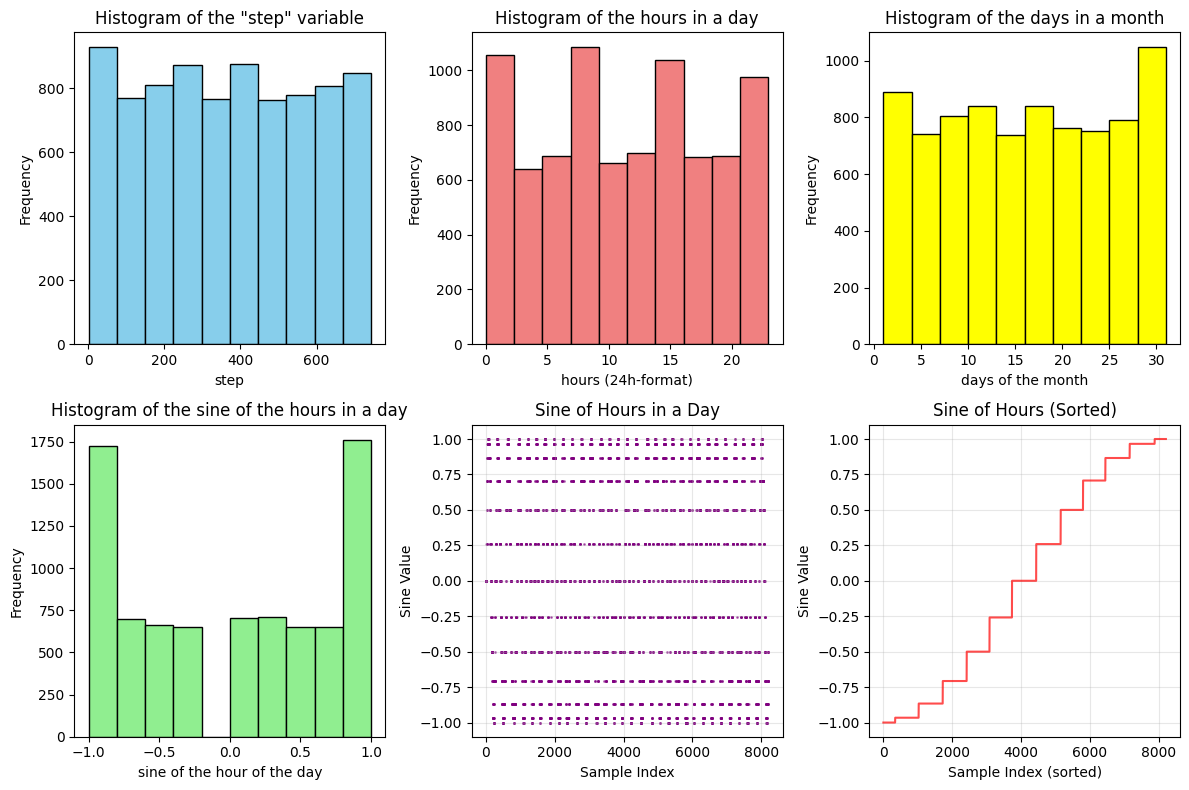

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

axes = axes.flatten()

axes[0].hist(step, edgecolor='black', color='skyblue')
axes[0].set_xlabel('step')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Histogram of the "step" variable')

axes[1].hist(hours, edgecolor='black', color='lightcoral')
axes[1].set_xlabel('hours (24h-format)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Histogram of the hours in a day')

axes[2].hist(days, edgecolor='black', color='yellow')
axes[2].set_xlabel('days of the month')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Histogram of the days in a month')

axes[3].hist(hour_sine, edgecolor='black', color='lightgreen')
axes[3].set_xlabel('sine of the hour of the day')
axes[3].set_ylabel('Frequency')
axes[3].set_title('Histogram of the sine of the hours in a day')

axes[4].scatter(range(len(hour_sine)), hour_sine, color='purple', alpha=0.3, s=1)
axes[4].set_xlabel('Sample Index')
axes[4].set_ylabel('Sine Value')
axes[4].set_title('Sine of Hours in a Day')
axes[4].grid(True, alpha=0.3)

# Downsample day_sine for line plots
downsample_factor = 100  # Plot every 100th point
hour_sine_downsampled = hour_sine[::downsample_factor]

hour_sine_sorted = np.sort(hour_sine)
axes[5].plot(hour_sine_sorted, color='red', linewidth=1.5, alpha=0.7)
axes[5].set_xlabel('Sample Index (sorted)')
axes[5].set_ylabel('Sine Value')
axes[5].set_title('Sine of Hours (Sorted)')
axes[5].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

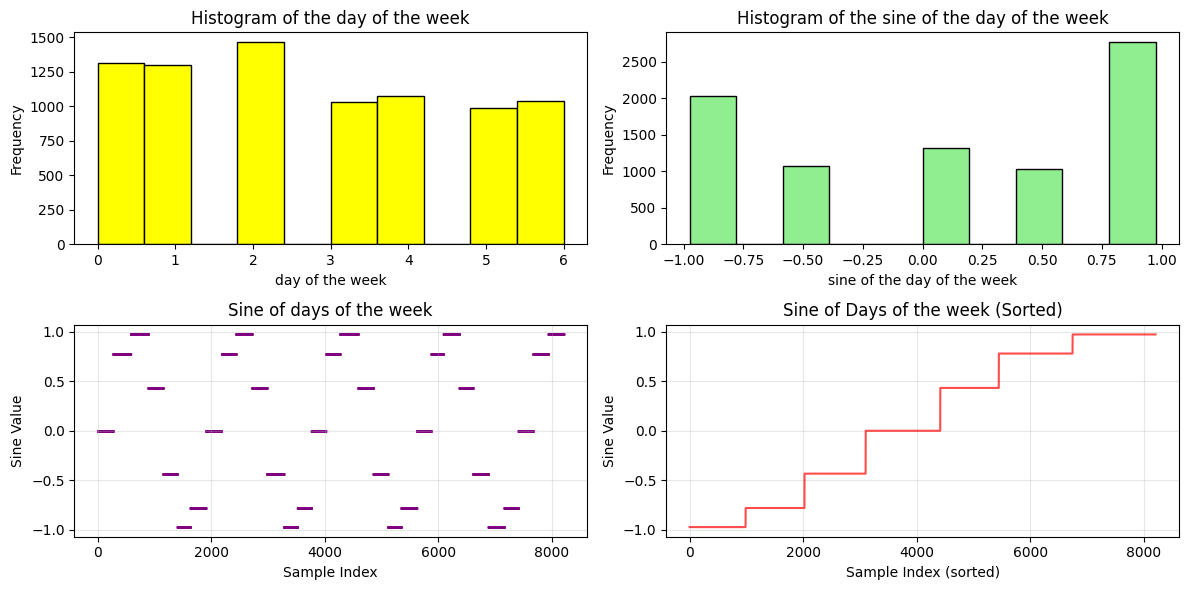

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

axes = axes.flatten()


axes[0].hist(day_of_week, edgecolor='black', color='yellow')
axes[0].set_xlabel('day of the week')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Histogram of the day of the week')

axes[1].hist(dow_sine, edgecolor='black', color='lightgreen')
axes[1].set_xlabel('sine of the day of the week')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Histogram of the sine of the day of the week')

axes[2].scatter(range(len(dow_sine)), dow_sine, color='purple', alpha=0.3, s=1)
axes[2].set_xlabel('Sample Index')
axes[2].set_ylabel('Sine Value')
axes[2].set_title('Sine of days of the week')
axes[2].grid(True, alpha=0.3)

# Downsample day_sine for line plots
downsample_factor = 100  # Plot every 100th point
dow_sine_downsampled = dow_sine[::downsample_factor]

dow_sine_sorted = np.sort(dow_sine)
axes[3].plot(dow_sine_sorted, color='red', linewidth=1.5, alpha=0.7)
axes[3].set_xlabel('Sample Index (sorted)')
axes[3].set_ylabel('Sine Value')
axes[3].set_title('Sine of Days of the week (Sorted)')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# Count fraud transactions per hour
fraud_per_hour = pd.Series(hours).value_counts().sort_index()

print("Fraud Transactions by Hour:")
print(fraud_per_hour)

# Identify peak fraud hours
peak_fraud_hours = fraud_per_hour.nlargest(5).index
print(f"\nTop 5 fraud hours: {peak_fraud_hours.tolist()}")

# Identify safe hours
safe_hours = fraud_per_hour.nsmallest(5).index
print(f"Safest hours: {safe_hours.tolist()}")

Fraud Transactions by Hour:
step
0     358
1     372
2     326
3     274
4     366
5     358
6     328
7     368
8     341
9     375
10    324
11    339
12    346
13    353
14    341
15    345
16    353
17    343
18    342
19    340
20    347
21    351
22    323
23    300
Name: count, dtype: int64

Top 5 fraud hours: [9, 1, 7, 4, 0]
Safest hours: [3, 23, 22, 10, 2]


In [15]:
# Count fraud transactions per days in a month
fraud_per_day = pd.Series(days).value_counts().sort_index()

print("Fraud Transactions by Day:")
print(fraud_per_day)

# Identify peak fraud days
peak_fraud_day = fraud_per_day.nlargest(5).index
print(f"\nTop 5 fraud days: {peak_fraud_day.tolist()}")

# Identify "safe days"
safe_days = fraud_per_day.nsmallest(5).index
print(f"Safest days: {safe_days.tolist()}")

Fraud Transactions by Day:
step
1     271
2     309
3     310
4     262
5     252
6     228
7     272
8     278
9     255
10    282
11    262
12    298
13    242
14    246
15    250
16    252
17    320
18    268
19    256
20    236
21    272
22    256
23    216
24    280
25    240
26    272
27    280
28    248
29    260
30    268
31    272
Name: count, dtype: int64

Top 5 fraud days: [17, 3, 2, 12, 10]
Safest days: [23, 6, 20, 25, 13]


In [16]:
# Count fraud transactions per days of the week
fraud_per_dow = pd.Series(day_of_week).value_counts().sort_index()

print("Fraud Transactions by Day of week:")
print(fraud_per_dow)

# Identify peak fraud days
peak_fraud_dow = fraud_per_dow.nlargest(5).index
print(f"\nTop 5 fraud days: {peak_fraud_dow.tolist()}")

# Identify "safe days"
safe_dow = fraud_per_dow.nsmallest(5).index
print(f"Safest days of the week: {safe_dow.tolist()}")

Fraud Transactions by Day of week:
step
0    1315
1    1300
2    1464
3    1032
4    1078
5     986
6    1038
Name: count, dtype: int64

Top 5 fraud days: [2, 0, 1, 4, 6]
Safest days of the week: [5, 3, 6, 4, 1]


### Notes

>**This shows that:**
>
>1. The highly skewed "amount" feature, benefits from logarithmic scaling
>
>2. The hours of the day, days in a week, sine of the days in a week, and sine of the hours are informative features
>
>3. The days in a month appears not to be very informative. This is due to it being linear and not cyclical as the hours of the day and the days in a week.

## Data Partitioning

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
y = dataset['isFraud']
X = dataset.drop('isFraud', axis=1)

In [19]:
y.value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [20]:
(y.value_counts() / y.shape[0]) * 100

isFraud
0    99.870918
1     0.129082
Name: count, dtype: float64

In [21]:
# First split: 70% train, 30% temp (test + validation)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.30,
    shuffle=True,
    stratify=y,
    random_state=RANDOM_NUMBER
)

# Second split: Split temp into 50-50 (15% test, 15% validation)
X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    shuffle=True,
    stratify=y_temp,
    random_state=RANDOM_NUMBER
)

In [22]:
print(f"Train Set\nX_Train: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print((y_train.value_counts() / y_train.shape[0]) * 100)
print('---------')
print(f"Test Set\nX_Test:  {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print((y_test.value_counts() / y_test.shape[0]) * 100)
print('---------')
print(f"Val Set\nX_Val:   {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print((y_val.value_counts() / y_val.shape[0]) * 100)

Train Set
X_Train: 4453834 (70.0%)
isFraud
0    99.87092
1     0.12908
Name: count, dtype: float64
---------
Test Set
X_Test:  954393 (15.0%)
isFraud
0    99.870913
1     0.129087
Name: count, dtype: float64
---------
Val Set
X_Val:   954393 (15.0%)
isFraud
0    99.870913
1     0.129087
Name: count, dtype: float64


### Notes

>**The Class Distribution is preserved across all splits**

## Feature Engineering

In [23]:
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from math import pi

In [24]:
def column_log(X):
    return np.log1p(X)

def make_hour(X):
    """Convert step to hours of the day (24h-format)"""
    return (X - 1) % 24

def make_hour_sine(X):
    """Sine encoding for hours of the day"""
    hour = make_hour(X)
    return np.sin((2 * pi * hour) / 24)

def make_day(X):
    """Convert step to days of the week (assumming 0=Monday, 6=Sunday)"""
    day = ((X - 1) // 24) + 1
    return (day - 1) % 7

def make_day_sine(X):
    """Sine encoding for day of week"""
    dow = make_day_of_week(X)
    return np.sin((2 * pi * dow) / 7)

def delta(X):
    result = X[X.columns[1]] - X[X.columns[0]]
    return result.values.reshape(-1, 1)

In [25]:
log_transformer = FunctionTransformer(
    func=column_log, 
    validate = False,
    feature_names_out = lambda transformer, input_features: [f"{name}_log" for name in input_features]
)

hour_transformer = FunctionTransformer(
    func=make_hour, 
    validate = False,
    feature_names_out = lambda transformer, input_features: ["hour"]
)

day_transformer = FunctionTransformer(
    func=make_day, 
    validate = False,
    feature_names_out = lambda transformer, input_features: ["day"]
)

hour_sine_transformer = FunctionTransformer(
    func=make_hour_sine, 
    validate = False,
    feature_names_out = lambda transformer, input_features: ["hour_sine"]
)

day_sine_transformer = FunctionTransformer(
    func=make_day_sine,
    validate = False,
    feature_names_out = lambda transformer, input_features: ["day_sine"]
)

delta_transformer = FunctionTransformer(
    func=delta, 
    validate = False,
    feature_names_out = lambda transformer, input_features: np.array(["deltaDest"]) if any("Dest" in name for name in input_features) else np.array(["deltaOrigin"])
)


In [26]:
preprocessor = ColumnTransformer(
    transformers = [
        ("log", log_transformer, ['amount']),
        ("hour", hour_transformer, ['step']),
        ("day", day_transformer, ['step']),
        ("h_sine", hour_sine_transformer, ['step']),
        ("d_sine", day_sine_transformer, ['step']),
        ("delta_origin", delta_transformer, ['oldbalanceOrg', 'newbalanceOrig']),
        ("delta_dest", delta_transformer, ['oldbalanceDest', 'newbalanceDest']),
        ("cat_feature", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), ['type'])
    ], remainder="drop"
)

In [27]:
# test_data = X_train.head(20).copy()

# trans_data = preprocessor.fit_transform(test_data)

# # Get feature names
# feature_names = preprocessor.get_feature_names_out()
# print("Feature names:", feature_names)

# # Convert to DataFrame
# trans_data_df = pd.DataFrame(trans_data, columns=feature_names)
# trans_data_df

## Application of SMOTE and Data Preparation

In [28]:
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.model_selection import (
    GridSearchCV, RandomizedSearchCV, 
    StratifiedKFold, cross_validate
)

from sklearn.metrics import (
    precision_recall_curve, auc, recall_score, matthews_corrcoef,
    precision_score, f1_score, roc_auc_score, roc_curve, 
    classification_report, make_scorer
)